# SafePrice Simulator
## Modeling

In [37]:
import pandas as pd
import numpy as np
import os
import mlflow
import optuna
import joblib
import xgboost as xgb
from interpret.glassbox import ExplainableBoostingRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

### 1) Preparation Data for Modeling

In [20]:
root_path = os.path.dirname(os.getcwd())

cleaned_datesets_path = os.path.join(root_path, 'datasets/cleaned')

retail_df = pd.read_csv(os.path.join(cleaned_datesets_path, "final_cleaned_retail_dataset.csv"))

retail_df.head()

,InvoiceDate,Quantity,Price,Retail Price Index,is_holiday
0,2010-01-04,3,0.85,859.6,0
1,2010-01-04,4,0.85,859.6,0
2,2010-01-04,3,3.25,859.6,0
3,2010-01-04,36,0.42,859.6,0
4,2010-01-04,2,4.25,859.6,0


In [21]:
print(retail_df.shape)
print(retail_df.dtypes)

(443918, 5)
InvoiceDate            object
Quantity                int64
Price                 float64
Retail Price Index    float64
is_holiday              int64
dtype: object


In [22]:
retail_df['InvoiceDate'] = pd.to_datetime(retail_df ['InvoiceDate'])

retail_df['month'] = retail_df['InvoiceDate'].dt.month
retail_df["day_of_week"] = retail_df['InvoiceDate'].dt.day_of_week

In [23]:
retail_df

,InvoiceDate,Quantity,Price,Retail Price Index,is_holiday,month,day_of_week
0,2010-01-04,3,0.85,859.6,0,1,0
1,2010-01-04,4,0.85,859.6,0,1,0
2,2010-01-04,3,3.25,859.6,0,1,0
3,2010-01-04,36,0.42,859.6,0,1,0
4,2010-01-04,2,4.25,859.6,0,1,0
...,...,...,...,...,...,...,...
443913,2011-12-09,3,1.63,944.4,0,12,4
443914,2011-12-09,1,2.49,944.4,0,12,4
443915,2011-12-09,5,2.46,944.4,0,12,4
443916,2011-12-09,3,2.49,944.4,0,12,4


#### Train Test Split

In [24]:
cutoff_date = pd.to_datetime('2011-05-31')

train_df = retail_df[retail_df['InvoiceDate'] <= cutoff_date]
test_df = retail_df[retail_df['InvoiceDate'] > cutoff_date]

In [25]:
featues = ['Price', 'Retail Price Index', 'is_holiday', 'month', 'day_of_week']
target = ['Quantity']

X_train = train_df[featues]
y_train = train_df[target]
X_test = test_df[featues]
y_test = test_df[target]

### Modeling

#### XGBoost Model

In [26]:
# xgb_model = xgb.XGBRFRegressor(
#     n_estimators=100, 
#     learning_rate=0.1, 
#     random_state=1111
# )

# xgb_model.fit(X_train, y_train)

# xgb_pred = xgb_model.predict(X_test)

# xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
# xgb_mae = mean_absolute_error(y_test, xgb_pred)

# print(f"XGBoost RMSE: {xgb_rmse:.2f}")
# print(f"XGBoost MAE: {xgb_mae:.2f}")

#### LSTM

In [27]:
# scaler_x = MinMaxScaler()
# scaler_y = MinMaxScaler()

# X_train_scaled = scaler_x.fit_transform(X_train)
# X_test_scaled = scaler_x.transform(X_test)
# y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
# X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# model = Sequential([
#     LSTM(32, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
#     Dropout(0.1),
#     Dense(1)
# ])

# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# model.fit(X_train_3d, y_train_scaled, epochs=10, batch_size=64, verbose=0)
# scaled_preds = model.predict(X_test_3d)
# lstm_preds = scaler_y.inverse_transform(scaled_preds).flatten()

# lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_preds))
# lstm_mae = mean_absolute_error(y_test, lstm_preds)

# print(f"LSTM RMSE: {lstm_rmse:.2f}")
# print(f"LSTM MAE: {lstm_mae:.2f}")

#### Explainable Boosting Machine

In [28]:
# ebm = ExplainableBoostingRegressor(random_state=1111)

# ebm.fit(X_train, y_train)

# ebm_pred = ebm.predict(X_test)
# ebm_rmse = np.sqrt(mean_squared_error(y_test, ebm_pred))
# ebm_mae = mean_absolute_error(y_test, ebm_pred)

# print(f"EBM RMSE: {ebm_rmse:.2f}")
# print(f"EBM MAE: {ebm_mae:.2f}")

### Hyperparameter Tuning with MLFLOW

In [29]:
# mlflow.set_tracking_uri("http://127.0.0.1:8080")
# mlflow.set_experiment("SafePrice_Model_Comparison")

In [30]:
# def tune_model(model_name, X_train, y_train, X_test, y_test, n_trials=10):
#     y_train_flat = y_train.values.ravel()
#     y_test_flat = y_test.values.ravel()

#     scaler_x = MinMaxScaler()
#     scaler_y = MinMaxScaler()

#     X_train_scaled = scaler_x.fit_transform(X_train)
#     X_test_scaled = scaler_x.transform(X_test)
#     y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

#     X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
#     X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

#     def objective(trial):

#         with mlflow.start_run(nested=True, run_name=f"Trial_{trial.number}"):

#             if model_name == "XGBoost":
#                 params = {
#                     "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
#                     "max_depth": trial.suggest_int("max_depth", 3, 10),
#                     "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#                     "subsample": trial.suggest_float("subsample", 0.5, 1.0)
#                 }
#                 model = xgb.XGBRegressor(**params, random_state=1111)
#                 mlflow.log_params(params)
#                 model.fit(X_train, y_train_flat)
#                 preds = model.predict(X_test)

#             elif model_name == 'EBM':
#                 params = {
#                     "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
#                     "max_bins": trial.suggest_int("max_bins", 32, 512),
#                     "interactions": trial.suggest_int("interactions", 5, 20),
#                     "outer_bags": 16
#                 }
#                 model = ExplainableBoostingRegressor(**params, random_state=1111)
#                 mlflow.log_params(params)
#                 model.fit(X_train, y_train_flat)
#                 preds = model.predict(X_test)

            
#             elif model_name == 'LSTM':
#                 units = trial.suggest_int("units", 32, 128)
#                 dropout = trial.suggest_float("dropout", 0.1, 0.4)
#                 lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

#                 model = Sequential([
#                     LSTM(units, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
#                     Dropout(dropout),
#                     Dense(1)
#                 ])

#                 model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')

#                 model.fit(X_train_3d, y_train_scaled, epochs=10, batch_size=64, verbose=0)

#                 mlflow.log_params({"units": units, "dropout": dropout, "learning_rate": lr})

#                 scaled_preds = model.predict(X_test_3d)
#                 preds = scaler_y.inverse_transform(scaled_preds).flatten()
        
#             rmse = np.sqrt(mean_squared_error(y_test_flat, preds))
#             mlflow.log_metric("rmse", rmse)

#             return rmse
        
#     with mlflow.start_run(run_name=f"{model_name}_Optimization"):
#         study = optuna.create_study(direction="minimize")
#         study.optimize(objective, n_trials=n_trials)

#         mlflow.log_params({f"best_{k}": v for k,v in study.best_params.items()})
#         mlflow.log_metric("best_rmse", study.best_value)
#         print(f"Finished {model_name} tuning. Best RMSE: {study.best_value:.4f}")
#         return study.best_params

In [31]:
# best_xgboost = tune_model("XGBoost", X_train, y_train, X_test, y_test)

In [32]:
# best_ebm = tune_model("EBM", X_train, y_train, X_test, y_test)

In [33]:
# best_lstm = tune_model("LSTM", X_train, y_train, X_test, y_test)

#### Best Models Saved

In [34]:
# models_path = os.path.join(root_path, 'models')
# joblib.dump(best_xgboost, os.path.join(models_path, 'best_xgboost_model.pkl'))
# joblib.dump(best_ebm, os.path.join(models_path, 'best_ebm_model.pkl'))
# joblib.dump(best_lstm, os.path.join(models_path, 'best_lstm_model.pkl'))
# print("Models Successfully Saved.")

### EBM Features Importance

In [39]:
models_path = os.path.join(root_path, 'models')
best_ebm_params = joblib.load(os.path.join(models_path, 'best_ebm_model.pkl'))


In [41]:
best_ebm_model = ExplainableBoostingRegressor(**best_ebm_params, random_state=1111)

best_ebm_model.fit(X_train, y_train.values.ravel())

ebm_global = best_ebm_model.explain_global(name='EBM Global Explanation')

ebm_data = ebm_global.data()
ebm_importance_df = pd.DataFrame({'Feature': ebm_data['names'], 'Importance': ebm_data['scores']})
ebm_importance_df = ebm_importance_df.sort_values(by='Importance', ascending=False)

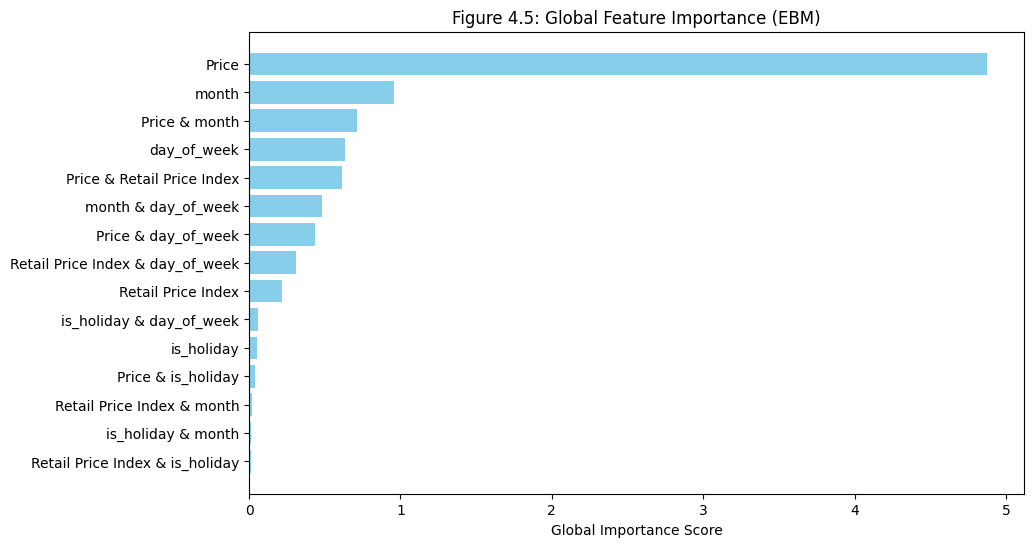

In [42]:
plt.figure(figsize=(10, 6))
plt.barh(ebm_importance_df['Feature'], ebm_importance_df['Importance'], color='skyblue')
plt.xlabel('Global Importance Score')
plt.title('Figure 4.5: Global Feature Importance (EBM)')
plt.gca().invert_yaxis()
plt.show()